# **Découverte des données**

In [152]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split

print("- Numpy version:", np.__version__)
print("- matplotlib version :", matplotlib.__version__)
print("- Pandas version:", pd.__version__)

df = pd.read_csv('./train_data_accidents.csv')

- Numpy version: 2.0.2
- matplotlib version : 3.10.0
- Pandas version: 2.2.2


In [153]:
df.describe()

,place,catu,sexe,trajet,secu1,secu2,secu3,locp,catv,an_nais,...,vosp,prof,plan,surf,infra,situ,lat,long,jour,grav
count,198448.000000,198448.000000,198448.000000,198448.00000,198448.000000,198448.000000,198448.000000,198448.000000,198448.000000,193851.000000,...,198448.000000,198448.000000,198448.000000,198448.000000,198448.000000,198448.000000,198448.000000,198448.000000,198448.000000,198448.000000
mean,1.738244,1.258471,1.260854,3.09925,1.800688,0.973459,-0.928853,-0.407946,12.204779,1983.126324,...,0.198989,1.227510,1.262688,1.254238,0.739070,1.363415,44.372023,2.424952,15.794329,2.455868
std,2.046079,0.521003,0.575758,2.79234,2.157863,3.013339,0.815751,0.962238,12.929179,18.196734,...,0.654632,0.540205,0.643377,0.783651,2.049499,1.269378,11.960855,18.732530,8.790684,1.399174
min,-1.000000,1.000000,-1.000000,-1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1912.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-23.395090,-176.218643,1.000000,-1.000000
25%,1.000000,1.000000,1.000000,0.00000,1.000000,-1.000000,-1.000000,-1.000000,7.000000,1971.000000,...,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,44.541917,1.418640,8.000000,1.000000
50%,1.000000,1.000000,1.000000,4.00000,1.000000,0.000000,-1.000000,-1.000000,7.000000,1986.000000,...,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,47.750755,2.403684,16.000000,3.000000
75%,1.000000,1.000000,2.000000,5.00000,2.000000,0.000000,-1.000000,0.000000,10.000000,1998.000000,...,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,48.858002,4.838890,23.000000,4.000000
max,10.000000,3.000000,2.000000,9.00000,9.000000,9.000000,9.000000,9.000000,99.000000,2021.000000,...,3.000000,4.000000,4.000000,9.000000,9.000000,8.000000,51.057332,168.106549,31.000000,4.000000


In [154]:
print(df.columns)

Index(['place', 'catu', 'sexe', 'trajet', 'secu1', 'secu2', 'secu3', 'locp',
       'catv', 'an_nais', 'mois', 'occutc', 'obs', 'obsm', 'choc', 'manv',
       'lum', 'agg', 'int', 'atm', 'col', 'catr', 'circ', 'vosp', 'prof',
       'plan', 'surf', 'infra', 'situ', 'lat', 'long', 'hrmn', 'jour', 'grav'],
      dtype='object')


Voici la heatmap des corrélations entre données

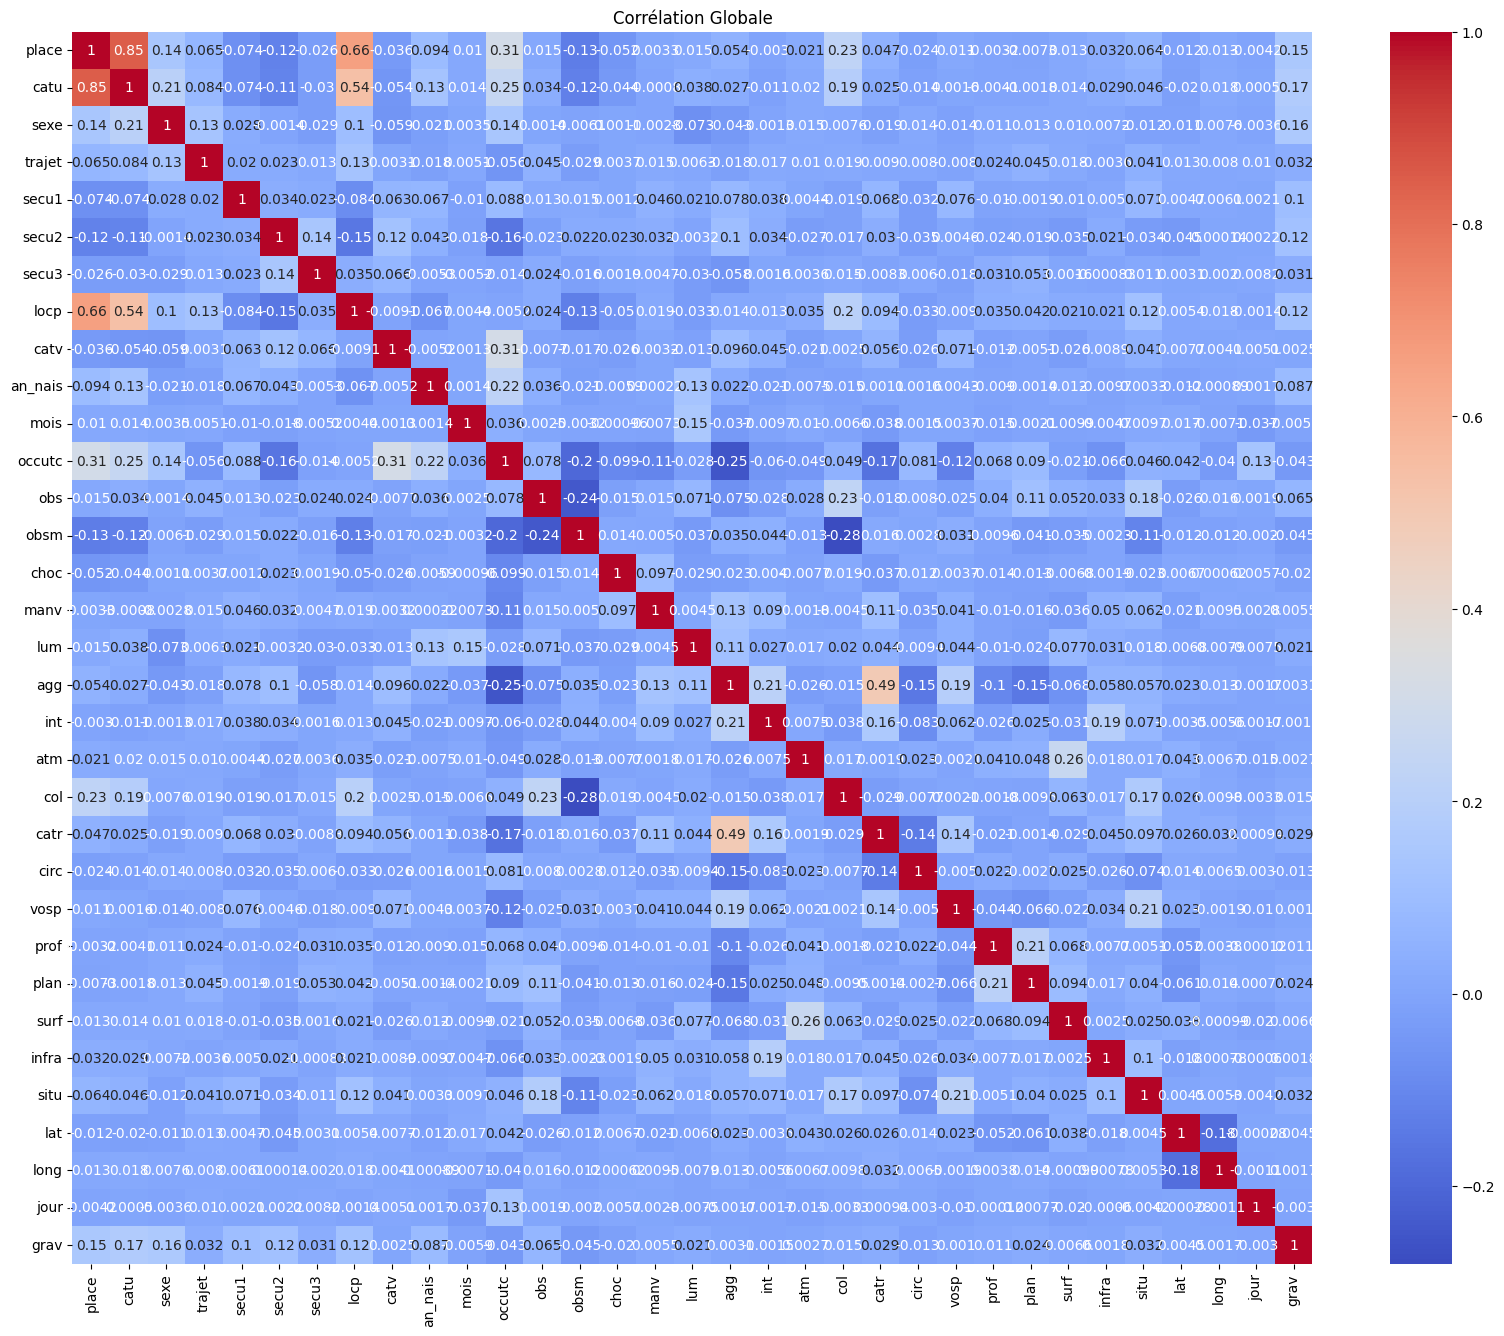

In [155]:
plt.figure(figsize=(20, 16))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Corrélation Globale")
plt.show()

On constate tout d'abord que certaines données sont inutilisables à cause de NaN à certains endroits

# **Nettoyage des données (suppression des NaN, des gravités de -1 etc.)**

In [156]:
del df['hrmn']
df.drop(df.index[(df['grav'] == -1)],axis=0,inplace=True)
df.drop(df.index[(df['an_nais'].isnull())],axis=0,inplace=True)
df.drop(df.index[(df['occutc'].isnull())],axis=0,inplace=True)

In [157]:
df.describe()

,place,catu,sexe,trajet,secu1,secu2,secu3,locp,catv,an_nais,...,vosp,prof,plan,surf,infra,situ,lat,long,jour,grav
count,1638.000000,1638.000000,1638.000000,1638.000000,1638.000000,1638.000000,1638.000000,1638.000000,1638.000000,1638.000000,...,1638.000000,1638.000000,1638.000000,1638.000000,1638.000000,1638.000000,1638.000000,1638.000000,1638.000000,1638.000000
mean,2.818681,1.433455,1.339438,3.354090,2.536630,0.688645,-0.992063,-0.340659,37.188034,1981.300977,...,0.708791,1.221001,1.260073,1.211844,1.060440,1.842491,44.659232,4.227565,15.735043,2.452381
std,3.015046,0.625388,0.473663,2.468696,2.963564,2.710554,0.250713,1.280919,0.390859,18.248382,...,1.238778,0.571144,0.637463,0.622079,2.518474,1.872438,13.126317,19.149032,8.955023,1.434326
min,1.000000,1.000000,1.000000,-1.000000,0.000000,-1.000000,-1.000000,-1.000000,37.000000,1924.000000,...,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,-22.293620,-149.570803,1.000000,1.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,37.000000,1968.000000,...,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,45.703240,2.137750,8.000000,1.000000
50%,1.000000,1.000000,1.000000,4.000000,1.000000,0.000000,-1.000000,-1.000000,37.000000,1983.000000,...,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,48.674750,2.394925,16.000000,3.000000
75%,4.000000,2.000000,2.000000,4.000000,2.000000,0.000000,-1.000000,0.000000,37.000000,1996.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,48.873447,4.656520,23.000000,4.000000
max,10.000000,3.000000,2.000000,9.000000,9.000000,9.000000,9.000000,9.000000,38.000000,2021.000000,...,3.000000,4.000000,4.000000,8.000000,9.000000,8.000000,50.726190,166.464640,31.000000,4.000000


# **Création du modèle, entraînement et résultats**

In [158]:
#séparation des données et des labels
labels = df['grav']
labels = labels - 1
df = df.drop(columns=["grav"])

#création des jeux d'entraînement et de test
x_train, x_test, y_train, y_test = train_test_split(df, labels, test_size=0.25, train_size=0.75)

In [161]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(500, 'linear'),
    tf.keras.layers.Dense(100, 'relu'),
    tf.keras.layers.Dense(50, 'linear'),
    tf.keras.layers.Dense(20, 'linear'),
    tf.keras.layers.Dense(10, 'relu'),
    tf.keras.layers.Dense(4, 'softmax'),
])
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
model.summary()
model.fit(x_train, y_train, epochs=20)
model.evaluate(x_test, y_test, verbose=2)

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_111 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_113 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_114 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_116 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3745 - loss: 72.5885
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4792 - loss: 1.3696
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4579 - loss: 1.3482
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5011 - loss: 1.3230
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4579 - loss: 1.3066
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4877 - loss: 1.2792
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4747 - loss: 1.2627
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4782 - loss: 1.2413
Epoch 9/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4651 - loss: 1.2292
Epoch 10/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4574 - loss: 1.2106
Epoch 11/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4732 - loss: 1.1949
Epoch 12/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4533

[1.0922870635986328, 0.49024391174316406]

In [162]:
predictions = model.predict(x_test)
probabilites = tf.nn.softmax(predictions).numpy()
print(probabilites)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
[[0.28400028 0.21875189 0.22191511 0.27533275]
 [0.28400028 0.21875189 0.22191511 0.27533275]
 [0.28400028 0.21875189 0.22191511 0.27533275]
 ...
 [0.28400028 0.21875189 0.22191511 0.27533275]
 [0.28400028 0.21875189 0.22191511 0.27533275]
 [0.28400028 0.21875189 0.22191511 0.27533275]]
